# Procedimento de Coleta



## Alfa de Cronbach

In [19]:
from google.colab import drive
import pandas as pd
import numpy as np

drive.mount('/content/drive')

df_alpha = pd.read_csv('/content/drive/MyDrive/ADM211/amostra_v2.csv')

colunas_numericas = [col for col in df_alpha.columns if col not in {'ID', 'Município', 'UF'}]

for col in colunas_numericas:
    df_alpha[col] = df_alpha[col].astype(str).str.replace(',', '.', regex=False)
    df_alpha[col] = pd.to_numeric(df_alpha[col], errors='coerce')

def alfa_cronbach_padronizado(dados: pd.DataFrame) -> float:
    dados = dados.dropna(axis=0, how='any')
    k = dados.shape[1]
    if k < 2:
        return np.nan

    matriz_corr = dados.corr().to_numpy()
    mascara = ~np.eye(k, dtype=bool)
    correlacoes = matriz_corr[mascara]
    correlacoes = correlacoes[~np.isnan(correlacoes)]

    if correlacoes.size == 0:
        return np.nan

    r_barra = correlacoes.mean()
    return float((k * r_barra) / (1 + (k - 1) * r_barra))

resultados = []
alpha_total = alfa_cronbach_padronizado(df_alpha[colunas_numericas])
resultados.append({
    'cenario': 'dataset completo',
    'variavel_removida': None,
    'n_variaveis': len(colunas_numericas),
    'alfa_padronizado': alpha_total,
})

for coluna_removida in colunas_numericas:
    subconjunto = [col for col in colunas_numericas if col != coluna_removida]
    alpha = alfa_cronbach_padronizado(df_alpha[subconjunto])
    resultados.append({
        'cenario': 'sem uma variável',
        'variavel_removida': coluna_removida,
        'n_variaveis': len(subconjunto),
        'alfa_padronizado': alpha,
    })

tabela_resultados = pd.DataFrame(resultados)
tabela_resultados = tabela_resultados.sort_values(
    by=['cenario', 'alfa_padronizado'],
    ascending=[True, False],
)

display(tabela_resultados)
print(f'Alpha padronizado do dataset completo: {alpha_total:.4f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,cenario,variavel_removida,n_variaveis,alfa_padronizado
0,dataset completo,None,4,0.455972
2,sem uma variável,areas_verdes_urbanas,3,0.732947
3,sem uma variável,focos_calor,3,0.282436
4,sem uma variável,emissao_co2_percapita,3,0.158065
1,sem uma variável,distancia_capital_regional_km,3,0.111878


Alpha padronizado do dataset completo: 0.4560


## Teste de Aleatoriedade

In [20]:
from google.colab import drive
import pandas as pd
import numpy as np
from math import erf, sqrt

# Mount Google Drive (if not already mounted)
drive.mount('/content/drive')

# Load the dataset from Google Drive
df_runs = pd.read_csv('/content/drive/MyDrive/ADM211/amostra_v2.csv')

# Identify numeric columns for the runs test
colunas_numericas_runs = [col for col in df_runs.columns if col not in {'ID', 'Município', 'UF'}]

# Treat numeric columns: replace comma with dot for decimals and convert to numeric
for col in colunas_numericas_runs:
    df_runs[col] = df_runs[col].astype(str).str.replace(',', '.', regex=False)
    df_runs[col] = pd.to_numeric(df_runs[col], errors='coerce')


def teste_runs_serie(serie: pd.Series) -> dict:
    serie = serie.dropna()
    if serie.nunique() < 2:
        return {
            'n': int(serie.shape[0]),
            'runs': np.nan,
            'z': np.nan,
            'p_valor': np.nan,
            'conclusao': 'sem variabilidade suficiente',
        }

    mediana = serie.median()
    sequencia = serie.map(lambda valor: 1 if valor >= mediana else 0)
    sequencia = sequencia[sequencia.notna()].to_numpy()

    if len(sequencia) < 2:
        return {
            'n': int(len(sequencia)),
            'runs': np.nan,
            'z': np.nan,
            'p_valor': np.nan,
            'conclusao': 'amostra insuficiente',
        }

    positivos = int(sequencia.sum())
    negativos = int(len(sequencia) - positivos)

    if positivos == 0 or negativos == 0:
        return {
            'n': int(len(sequencia)),
            'runs': np.nan,
            'z': np.nan,
            'p_valor': np.nan,
            'conclusao': 'todos os valores caem no mesmo lado da mediana',
        }

    runs = 1 + int(np.sum(sequencia[1:] != sequencia[:-1]))
    n1 = positivos
    n2 = negativos
    n = n1 + n2
    media_runs = (2 * n1 * n2) / n + 1
    variancia_runs = (2 * n1 * n2 * (2 * n1 * n2 - n)) / (n**2 * (n - 1))

    if variancia_runs <= 0:
        return {
            'n': int(n),
            'runs': runs,
            'z': np.nan,
            'p_valor': np.nan,
            'conclusao': 'variância nula no teste',
        }

    z = (runs - media_runs) / sqrt(variancia_runs)
    p_valor = 2 * (1 - 0.5 * (1 + erf(abs(z) / sqrt(2))))

    return {
        'n': int(n),
        'runs': int(runs),
        'z': float(z),
        'p_valor': float(p_valor),
        'conclusao': 'sequência aleatória' if p_valor >= 0.05 else 'sequência não aleatória',
    }

resultados_runs = []
for coluna in colunas_numericas_runs:
    resultado = teste_runs_serie(df_runs[coluna])
    resultado['variavel'] = coluna
    resultados_runs.append(resultado)

tabela_runs = pd.DataFrame(resultados_runs)
tabela_runs = tabela_runs[['variavel', 'n', 'runs', 'z', 'p_valor', 'conclusao']].sort_values('p_valor', ascending=True)

display(tabela_runs)
print('Teste de aleatoriedade concluído com p-valor bilateral por variável numérica.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,variavel,n,runs,z,p_valor,conclusao
3,emissao_co2_percapita,100,46,-1.005089,0.314854,sequência aleatória
0,distancia_capital_regional_km,100,55,0.804071,0.421356,sequência aleatória
1,areas_verdes_urbanas,100,54,0.603053,0.546473,sequência aleatória
2,focos_calor,100,53,0.402036,0.687658,sequência aleatória


Teste de aleatoriedade concluído com p-valor bilateral por variável numérica.


## Cálculo do Tamanho da Amostra

In [21]:
from google.colab import drive
import numpy as np
import pandas as pd

drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/ADM211/amostra_v2.csv')

colunas_numericas = [col for col in df.columns if col not in {'ID', 'Município', 'UF'}]

for col in colunas_numericas:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

N = 786
z = 1.96

erros_desejados = {
    'distancia_capital_regional_km': 20,
    'areas_verdes_urbanas': 1,
    'emissao_co2_percapita': 2,
    'focos_calor': 2,
}

res = []
for col in colunas_numericas:
    x = df[col].dropna()
    if len(x) < 2:
        var = np.nan
    else:
        var = float(x.var(ddof=1))
    E_desejado = erros_desejados.get(col, np.nan)

    if np.isnan(E_desejado) or np.isnan(var) or var <= 0:
        n_calc = np.nan
        n_obs = np.nan
        complemento = np.nan
        erro_obt = np.nan
    else:
        n0 = (z**2 * var) / (E_desejado**2)
        n_calc = (N * n0) / (N + n0)
        n_obs = int(np.ceil(n_calc))
        complemento = N - n_obs
        erro_obt = float(np.sqrt(((N - n_obs) / (N - 1)) * (var / n_obs))) if n_obs > 0 and (N - 1) > 0 else np.nan

    res.append({
        'variavel': col,
        'variancia': var,
        'n': n_obs,
        'complemento_n': complemento,
        'erro_desejado': E_desejado,
        'erro_obtido': erro_obt,
    })

tabela_n = pd.DataFrame(res)
tabela_n = tabela_n[['variavel', 'variancia', 'n', 'complemento_n', 'erro_desejado', 'erro_obtido']]
tabela_n['variancia'] = tabela_n['variancia'].round(4)
tabela_n['erro_desejado'] = tabela_n['erro_desejado'].round(4)
tabela_n['erro_obtido'] = tabela_n['erro_obtido'].round(4)

display(tabela_n)
print('População total:', N)
print('Confiança:', '95%')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,variavel,variancia,n,complemento_n,erro_desejado,erro_obtido
0,distancia_capital_regional_km,8219.4622,72,714,20,10.1899
1,areas_verdes_urbanas,8.9383,33,753,1,0.5097
2,focos_calor,90.2515,79,707,2,1.0144
3,emissao_co2_percapita,74.3846,66,720,2,1.0167


População total: 786
Confiança: 95%


## Tratamento dos Dados

### Carregamento da amostra no Google Colab

In [22]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/ADM211/amostra_v2.csv')

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,ID,Município,UF,distancia_capital_regional_km,areas_verdes_urbanas,focos_calor,emissao_co2_percapita
0,407,Várzea da Roça,BA,146.934,"1,16","2,17","5,11"
1,337,Santa Bárbara,BA,35.020,"2,41","0,48","2,88"
2,538,Passira,PE,53.398,"4,32",0,"2,83"
3,716,Missão Velha,CE,18.663,"1,28","13,58","4,94"
4,298,Piatã,BA,215.275,"5,67","4,48","9,53"


### Tratando inconsistência de separadores decimais

In [23]:
colunas_numericas_para_tratar = [
    'distancia_capital_regional_km',
    'areas_verdes_urbanas',
    'focos_calor',
    'emissao_co2_percapita',
]

for col in colunas_numericas_para_tratar:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Colunas numéricas tratadas para float:")
df.head()

Colunas numéricas tratadas para float:


,ID,Município,UF,distancia_capital_regional_km,areas_verdes_urbanas,focos_calor,emissao_co2_percapita
0,407,Várzea da Roça,BA,146.934,1.16,2.17,5.11
1,337,Santa Bárbara,BA,35.020,2.41,0.48,2.88
2,538,Passira,PE,53.398,4.32,0.00,2.83
3,716,Missão Velha,CE,18.663,1.28,13.58,4.94
4,298,Piatã,BA,215.275,5.67,4.48,9.53


### Tratando Outliers

#### Antes

### Box-plots Antes da Remoção de Outliers ###



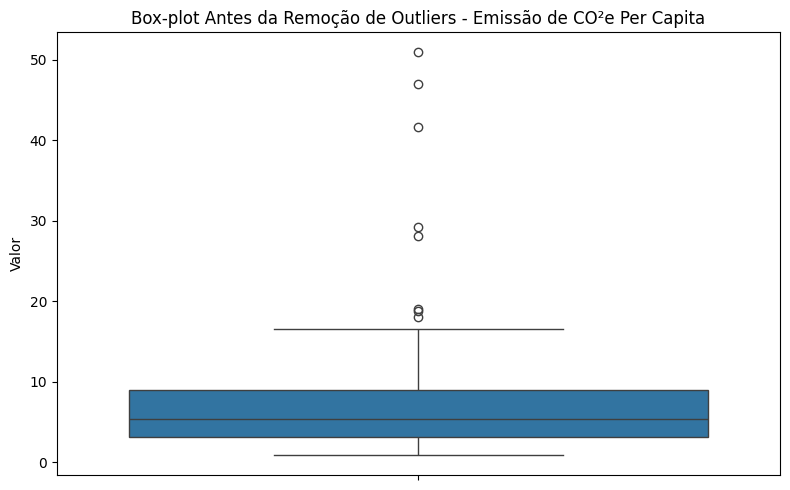

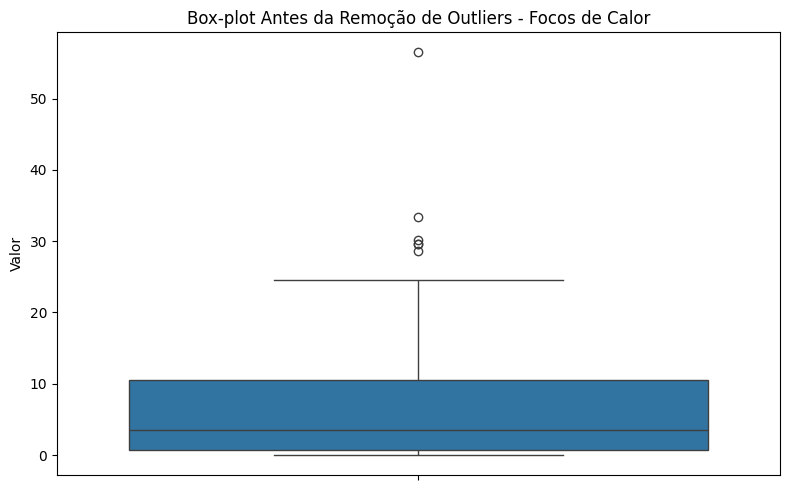

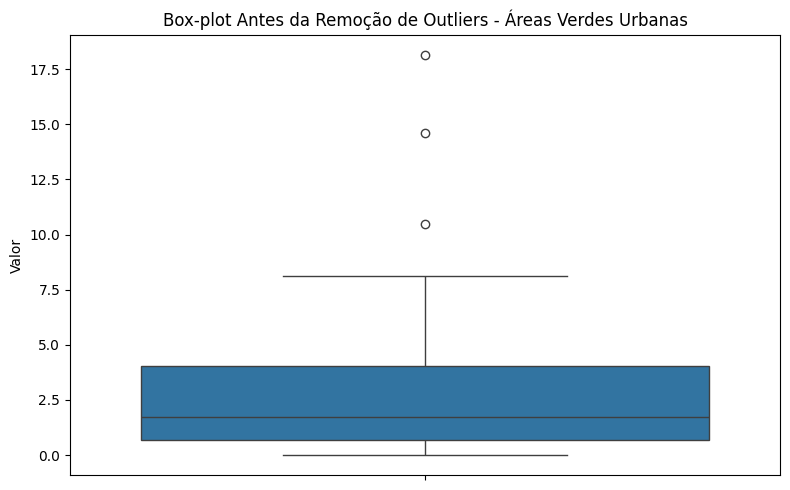

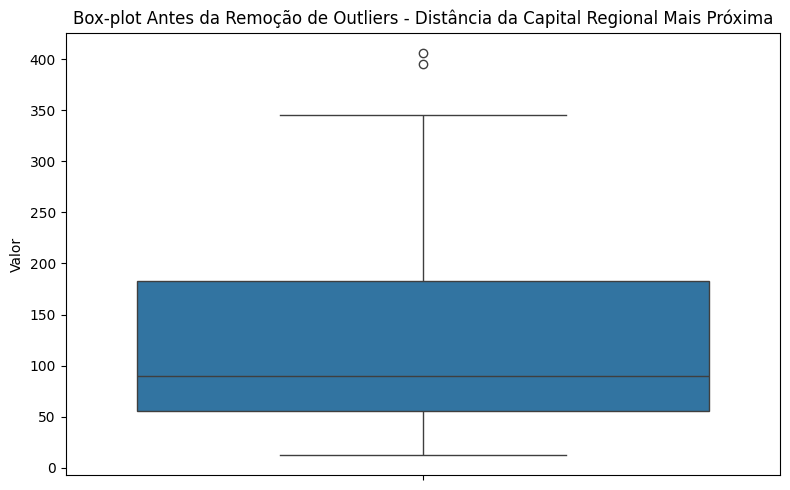

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Carregar o DataFrame original para a comparação antes do tratamento de outliers
df_before_outliers_plot = pd.read_csv('/content/drive/MyDrive/ADM211/amostra_v2.csv')

# Reaplicar o tratamento de separadores decimais (necessário para o arquivo lido diretamente)
colunas_numericas_para_tratar_before_plot = [
    'distancia_capital_regional_km',
    'areas_verdes_urbanas',
    'focos_calor',
    'emissao_co2_percapita',
]

for col in colunas_numericas_para_tratar_before_plot:
    df_before_outliers_plot[col] = df_before_outliers_plot[col].astype(str).str.replace(',', '.', regex=False)
    df_before_outliers_plot[col] = pd.to_numeric(df_before_outliers_plot[col], errors='coerce')

columns_to_plot = [
    'emissao_co2_percapita',
    'focos_calor',
    'areas_verdes_urbanas',
    'distancia_capital_regional_km'
]

print("### Box-plots Antes da Remoção de Outliers ###\n")

for col in columns_to_plot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df_before_outliers_plot[col])
    if col == 'distancia_capital_regional_km':
      plt.title(f'Box-plot Antes da Remoção de Outliers - Distância da Capital Regional Mais Próxima')
      plt.ylabel('Distância em Km')
    elif col == 'areas_verdes_urbanas':
      plt.title(f'Box-plot Antes da Remoção de Outliers - Áreas Verdes Urbanas')
      plt.ylabel('Valor')
    elif col == 'focos_calor':
      plt.title(f'Box-plot Antes da Remoção de Outliers - Focos de Calor')
      plt.ylabel('Valor')
    elif col == 'emissao_co2_percapita':
      plt.title(f'Box-plot Antes da Remoção de Outliers - Emissão de CO²e Per Capita')
      plt.ylabel('Valor')
    plt.ylabel('Valor')
    plt.tight_layout()
    plt.show()

#### Depois

### Iniciando Tratamento de Outliers ###

Outliers removidos da coluna 'emissao_co2_percapita'. Foram removidas 8 linhas. Valores fora de [-5.56, 17.57] foram removidos.
Outliers removidos da coluna 'focos_calor'. Foram removidas 7 linhas. Valores fora de [-12.46, 22.37] foram removidos.
Outliers removidos da coluna 'areas_verdes_urbanas'. Foram removidas 3 linhas. Valores fora de [-4.41, 9.27] foram removidos.

DataFrame após remoção de outliers salvo em: /content/drive/MyDrive/ADM211/amostra_v3.csv

DataFrame após remoção de outliers (primeiras 5 linhas):


,ID,Município,UF,distancia_capital_regional_km,areas_verdes_urbanas,focos_calor,emissao_co2_percapita
0,407,Várzea da Roça,BA,146.934,1.16,2.17,5.11
1,337,Santa Bárbara,BA,35.020,2.41,0.48,2.88
2,538,Passira,PE,53.398,4.32,0.00,2.83
3,716,Missão Velha,CE,18.663,1.28,13.58,4.94
4,298,Piatã,BA,215.275,5.67,4.48,9.53



### Box-plots Depois da Remoção de Outliers ###



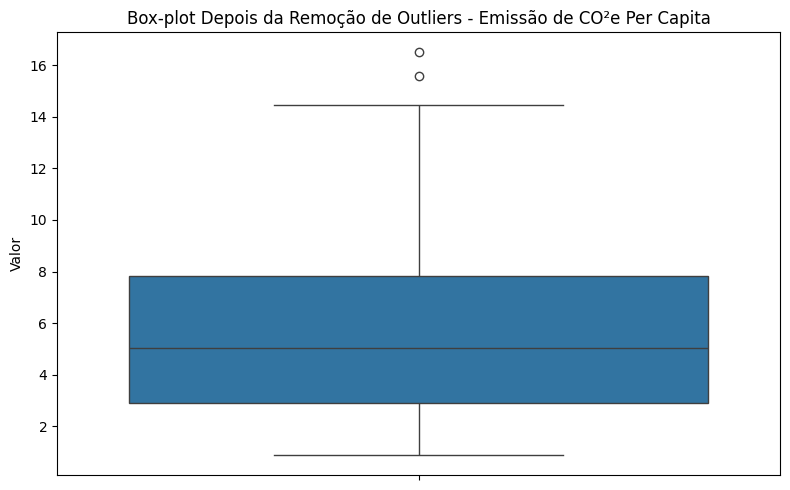

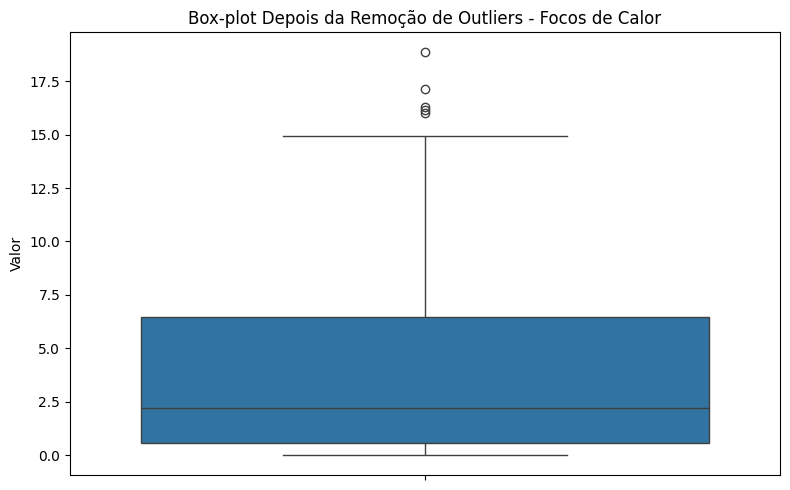

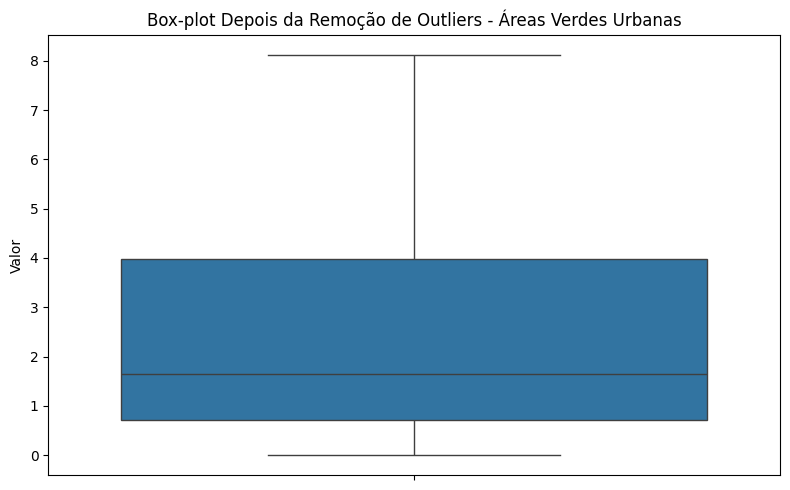

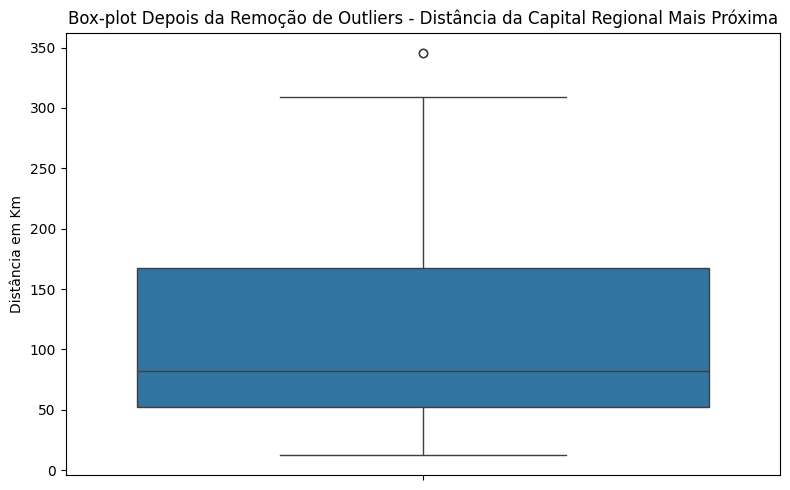

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Carregar o DataFrame original para garantir que o tratamento seja feito do zero
df = pd.read_csv('/content/drive/MyDrive/ADM211/amostra_v2.csv')

# Reaplicar o tratamento de separadores decimais para as colunas numéricas
colunas_numericas_para_tratar = [
    'distancia_capital_regional_km',
    'areas_verdes_urbanas',
    'focos_calor',
    'emissao_co2_percapita',
]

for col in colunas_numericas_para_tratar:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Função para remover outliers usando o método IQR
def remove_outliers_iqr(df_input, column):
    Q1 = df_input[column].quantile(0.25)
    Q3 = df_input[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    initial_rows = len(df_input)
    df_filtered = df_input[(df_input[column] >= lower_bound) & (df_input[column] <= upper_bound)]
    removed_rows = initial_rows - len(df_filtered)
    print(f"Outliers removidos da coluna '{column}'. Foram removidas {removed_rows} linhas. Valores fora de [{lower_bound:.2f}, {upper_bound:.2f}] foram removidos.")
    return df_filtered

# Colunas para as quais o tratamento de outliers será aplicado
columns_to_clean = [
    'emissao_co2_percapita',
    'focos_calor',
    'areas_verdes_urbanas'
]

# Aplicar a remoção de outliers
print("### Iniciando Tratamento de Outliers ###\n")
for col in columns_to_clean:
    df = remove_outliers_iqr(df, col)

# Salvar o DataFrame após a remoção de outliers
output_path_v3 = '/content/drive/MyDrive/ADM211/amostra_v3.csv'
df.to_csv(output_path_v3, index=False)
print(f"\nDataFrame após remoção de outliers salvo em: {output_path_v3}")

print("\nDataFrame após remoção de outliers (primeiras 5 linhas):")
display(df.head())

# Gerar box-plots depois da remoção de outliers
columns_to_plot_after = [
    'emissao_co2_percapita',
    'focos_calor',
    'areas_verdes_urbanas',
    'distancia_capital_regional_km' # Incluir também para visualização, mesmo que não tenha tido remoção específica
]

print("\n### Box-plots Depois da Remoção de Outliers ###\n")

for col in columns_to_plot_after:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df[col])
    if col == 'distancia_capital_regional_km':
      plt.title(f'Box-plot Depois da Remoção de Outliers - Distância da Capital Regional Mais Próxima')
      plt.ylabel('Distância em Km')
    elif col == 'areas_verdes_urbanas':
      plt.title(f'Box-plot Depois da Remoção de Outliers - Áreas Verdes Urbanas')
      plt.ylabel('Valor')
    elif col == 'focos_calor':
      plt.title(f'Box-plot Depois da Remoção de Outliers - Focos de Calor')
      plt.ylabel('Valor')
    elif col == 'emissao_co2_percapita':
      plt.title(f'Box-plot Depois da Remoção de Outliers - Emissão de CO²e Per Capita')
      plt.ylabel('Valor')
    else:
      plt.title(f'Box-plot Depois da Remoção de Outliers - {col}')
      plt.ylabel('Valor')

    plt.tight_layout()
    plt.show()


### Box-plots Depois da Remoção de Outliers ###



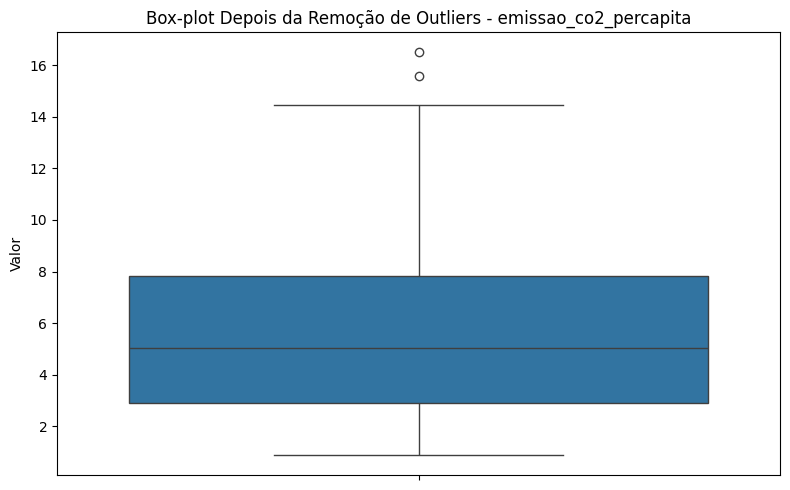

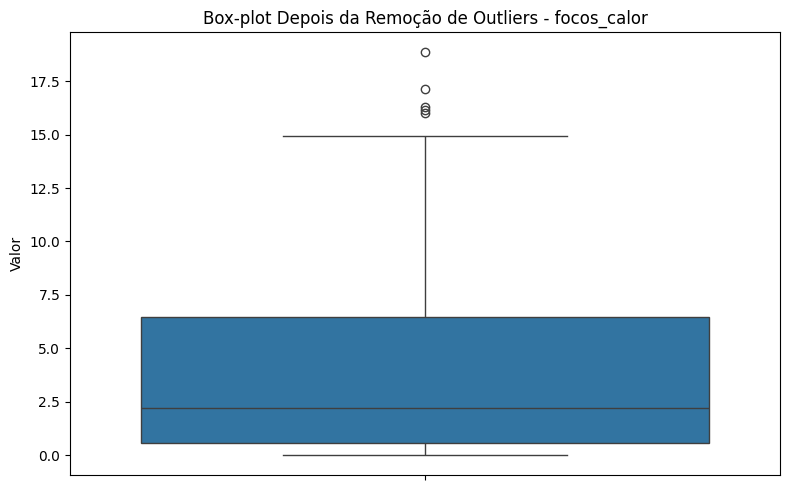

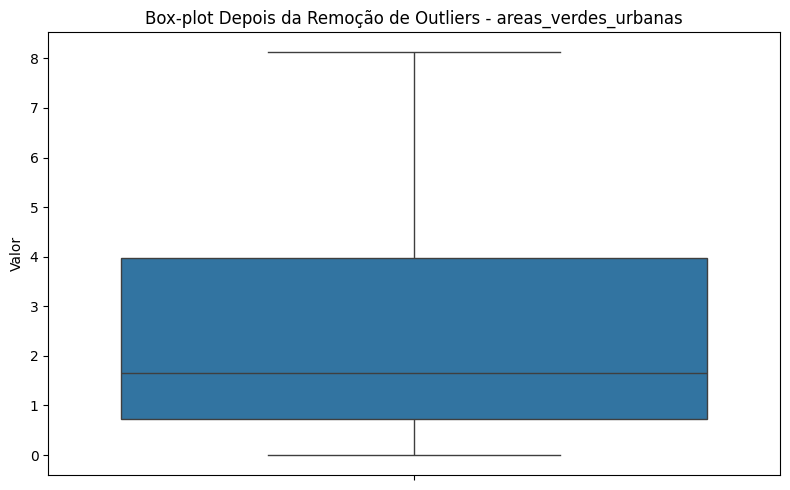

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# df_after_outliers é o 'df' atual no ambiente, após a remoção de outliers pela célula anterior
df_after_outliers_plot = df.copy()

columns_to_plot = [
    'emissao_co2_percapita',
    'focos_calor',
    'areas_verdes_urbanas'
]

print("### Box-plots Depois da Remoção de Outliers ###\n")

for col in columns_to_plot:
    plt.figure(figsize=(8, 5))
    sns.boxplot(y=df_after_outliers_plot[col])
    plt.title(f'Box-plot Depois da Remoção de Outliers - {col}')
    plt.ylabel('Valor')
    plt.tight_layout()
    plt.show()

### Padronização (Escalonamento)

In [27]:
from sklearn.preprocessing import StandardScaler

df_scaled = df.copy()

scaler = StandardScaler()

columns_to_scale = [
    'distancia_capital_regional_km',
    'areas_verdes_urbanas',
    'focos_calor',
    'emissao_co2_percapita',
]

existing_columns_to_scale = [col for col in columns_to_scale if col in df_scaled.columns]

if existing_columns_to_scale:
    df_scaled[existing_columns_to_scale] = scaler.fit_transform(df_scaled[existing_columns_to_scale])
    print("Variáveis numéricas padronizadas:")
    display(df_scaled[existing_columns_to_scale].head())
else:
    print("Nenhuma das colunas para padronizar foi encontrada no DataFrame.")

output_path = '/content/drive/MyDrive/ADM211/amostra_escalonada.csv'
df_scaled.to_csv(output_path, index=False)

print(f"\nDataFrame padronizado salvo em: {output_path}")

Variáveis numéricas padronizadas:


,distancia_capital_regional_km,areas_verdes_urbanas,focos_calor,emissao_co2_percapita
0,0.445221,-0.590981,-0.459489,-0.196756
1,-0.968627,0.007296,-0.789450,-0.783876
2,-0.736451,0.921463,-0.883167,-0.797040
3,-1.175270,-0.533546,1.768238,-0.241514
4,1.308597,1.567602,-0.008476,0.966953



DataFrame padronizado salvo em: /content/drive/MyDrive/ADM211/amostra_escalonada.csv


# Técnicas e Modelos de Análise

## Sumarização

### Resumo Estatístico

In [31]:
print("### Medidas Descritivas por Variável (DataFrame Padronizado) ###\n")

# Identify numerical columns for statistical analysis from the scaled DataFrame
# Using the same list from the previous scaling step
numerical_cols_for_stats = [
    'distancia_capital_regional_km',
    'areas_verdes_urbanas',
    'focos_calor',
    'emissao_co2_percapita',
]

stats_per_variable = pd.DataFrame(index=['Média', 'Erro padrão', 'Moda', 'Mediana', 'Primeiro Quartil', 'Terceiro Quartil', 'Variância', 'Desvio Padrão', 'Curtose', 'Inclinação', 'Intervalo', 'Mínimo', 'Máximo', 'Soma', 'Contagem'])

for col in numerical_cols_for_stats:
    if col in df.columns:
        stats_per_variable[col] = [
            df[col].mean(),
            df[col].sem(),
            df[col].mode()[0] if not df[col].mode().empty else 'N/A',
            df[col].median(),
            df[col].quantile(0.25),
            df[col].quantile(0.75),
            df[col].var(),
            df[col].std(),
            df[col].kurtosis(),
            df[col].skew(),
            df[col].max() - df[col].min(),
            df[col].min(),
            df[col].max(),
            df[col].sum(),
            df[col].count()
        ]

display(stats_per_variable.round(2))


### Medidas Descritivas por Variável (DataFrame Padronizado) ###



,distancia_capital_regional_km,areas_verdes_urbanas,focos_calor,emissao_co2_percapita
Média,111.69,2.39,4.52,5.86
Erro padrão,8.80,0.23,0.57,0.42
Moda,12.49,0.00,0.00,2.10
Mediana,82.30,1.66,2.20,5.04
Primeiro Quartil,52.24,0.72,0.58,2.89
Terceiro Quartil,167.63,3.98,6.46,7.84
Variância,6342.96,4.42,26.56,14.60
Desvio Padrão,79.64,2.10,5.15,3.82
Curtose,0.39,0.06,0.35,0.24
Inclinação,0.98,0.93,1.21,0.97


### Box-plots

### Gráficos Box-plot das Variáveis Padronizadas ###



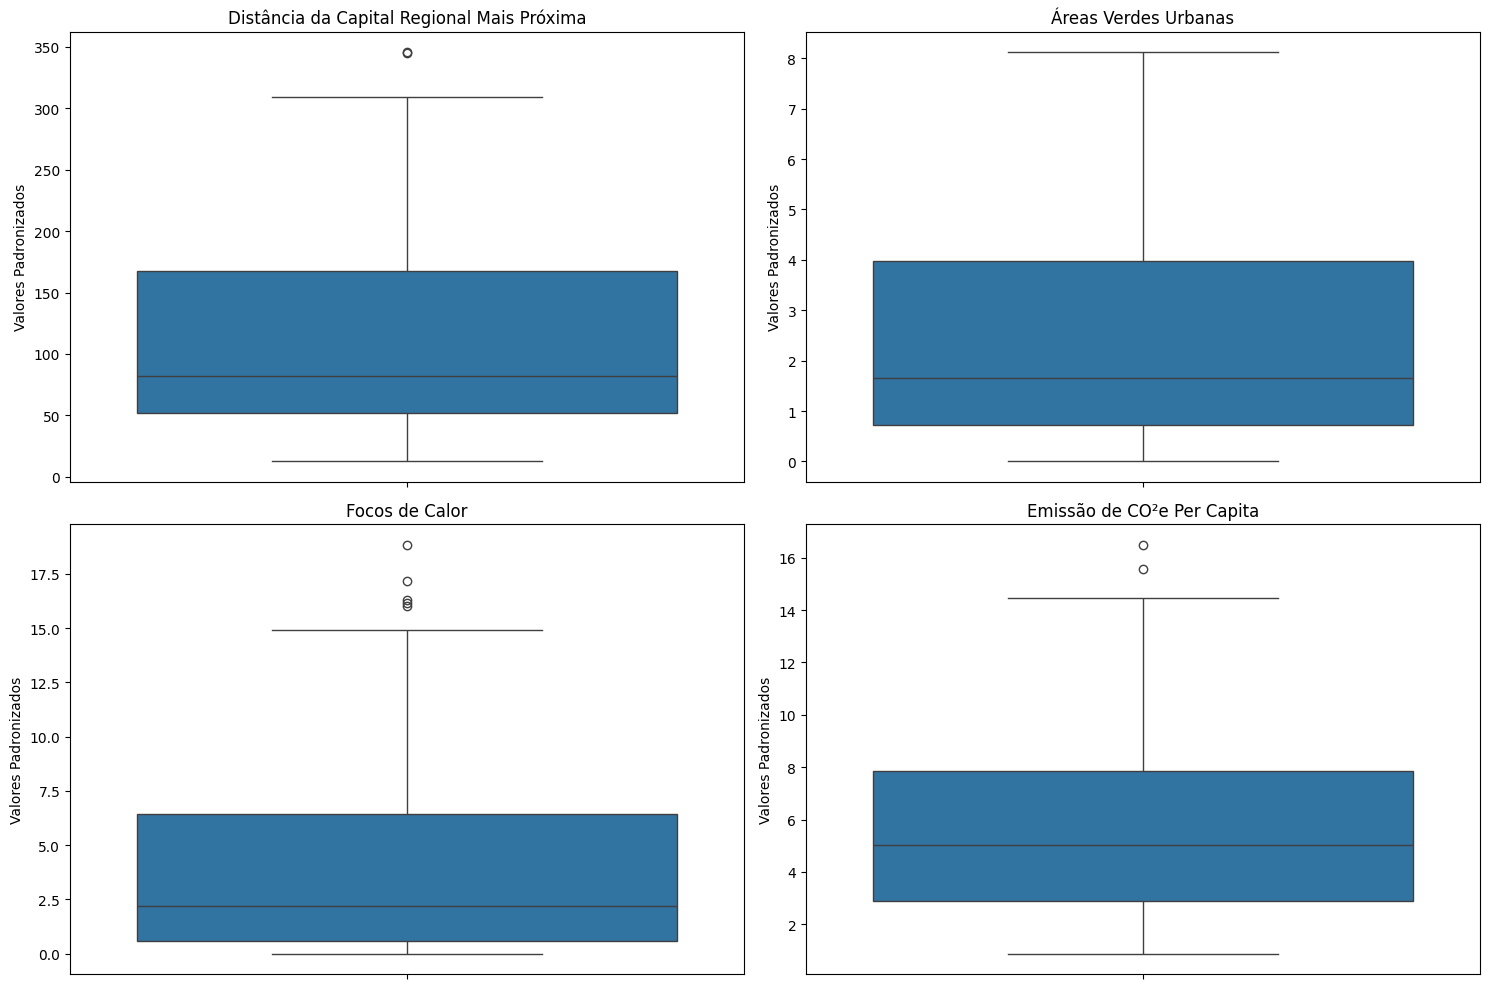

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the numerical columns to plot
# Using the list of columns that were scaled previously
numerical_cols_to_plot = [
    'distancia_capital_regional_km',
    'areas_verdes_urbanas',
    'focos_calor',
    'emissao_co2_percapita',
]

print("### Gráficos Box-plot das Variáveis Padronizadas ###\n")

# Create a figure to hold all subplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(numerical_cols_to_plot):
    if col in df.columns:
        plt.subplot(2, 2, i + 1)  # Adjust subplot grid as needed
        sns.boxplot(y=df[col])
        if col == 'distancia_capital_regional_km':
          plt.title(f'Distância da Capital Regional Mais Próxima')
        elif col == 'areas_verdes_urbanas':
          plt.title(f'Áreas Verdes Urbanas')
        elif col == 'focos_calor':
          plt.title(f'Focos de Calor')
        elif col == 'emissao_co2_percapita':
          plt.title(f'Emissão de CO²e Per Capita')
        plt.ylabel('Valores Padronizados')

plt.tight_layout()
plt.show()


## Agrupamento

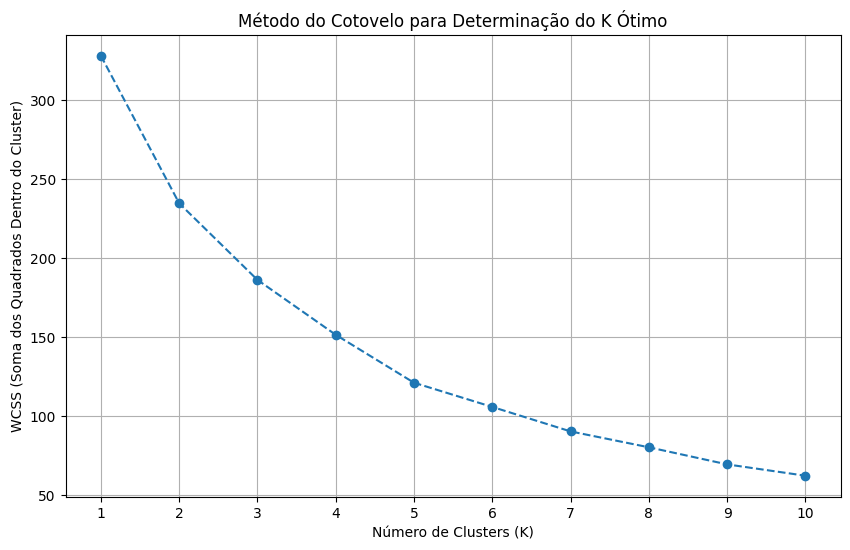

O gráfico acima mostra a Soma dos Quadrados Dentro do Cluster (WCSS) para diferentes números de clusters (K).
O ponto onde a curva forma um 'cotovelo' (a diminuição do WCSS começa a desacelerar) sugere um K ideal.

Aplicando K-Means com K=4 clusters...

DataFrame com clusters salvo em: /content/drive/MyDrive/ADM211/amostra_clusters.csv

DataFrame padronizado com as atribuições de cluster (primeiras 5 linhas, K=4):


,ID,Município,UF,Distância da Capital Regional,Áreas Verdes Urbanas,Focos de Calor,Emissão de CO²e Per Capita,Cluster
0,407,Várzea da Roça,BA,0.445221,-0.590981,-0.459489,-0.196756,1
1,337,Santa Bárbara,BA,-0.968627,0.007296,-0.789450,-0.783876,1
2,538,Passira,PE,-0.736451,0.921463,-0.883167,-0.797040,2
3,716,Missão Velha,CE,-1.175270,-0.533546,1.768238,-0.241514,3
4,298,Piatã,BA,1.308597,1.567602,-0.008476,0.966953,0


In [37]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd
import seaborn as sns

df_renomeado = df_scaled.rename(columns={
    'distancia_capital_regional_km': 'Distância da Capital Regional',
    'areas_verdes_urbanas': 'Áreas Verdes Urbanas',
    'focos_calor': 'Focos de Calor',
    'emissao_co2_percapita': 'Emissão de CO²e Per Capita'
})

existing_columns_to_scale = [
    'Distância da Capital Regional',
    'Áreas Verdes Urbanas',
    'Focos de Calor',
    'Emissão de CO²e Per Capita'
]

X = df_renomeado[existing_columns_to_scale]

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método do Cotovelo para Determinação do K Ótimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Soma dos Quadrados Dentro do Cluster)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

print("O gráfico acima mostra a Soma dos Quadrados Dentro do Cluster (WCSS) para diferentes números de clusters (K).")
print("O ponto onde a curva forma um 'cotovelo' (a diminuição do WCSS começa a desacelerar) sugere um K ideal.")

k = 4

print(f"\nAplicando K-Means com K={k} clusters...")
kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

df_renomeado['Cluster'] = clusters

output_path = '/content/drive/MyDrive/ADM211/amostra_clusters.csv'
df_renomeado.to_csv(output_path, index=False)

print(f"\nDataFrame com clusters salvo em: {output_path}")

print(f"\nDataFrame padronizado com as atribuições de cluster (primeiras 5 linhas, K={k}):")
display(df_renomeado.head())

## Associação

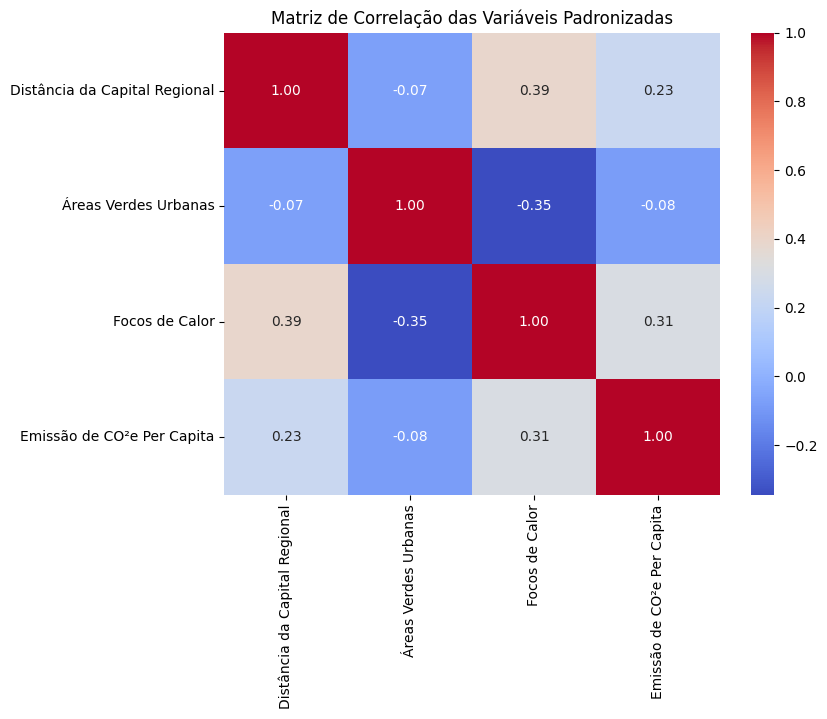

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

correlation_matrix = df_renomeado[existing_columns_to_scale].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Variáveis Padronizadas')
plt.show()


## Regressão

In [39]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

y = df_renomeado['Emissão de CO²e Per Capita']

X = df_renomeado[[
    'Distância da Capital Regional',
    'Áreas Verdes Urbanas',
    'Focos de Calor'
]]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

r_squared = model.rsquared
adj_r_squared = model.rsquared_adj
std_error_reg = np.sqrt(model.mse_resid)
n_variables = X.shape[1] - 1
n_observations = len(y)
significance = model.f_pvalue

summary_data = {
    'Métrica': ['R²', 'R² Ajustado', 'Erro Padrão da Regressão', 'Variáveis (Excl. Intercepto)', 'Observações', 'Significância (p-valor do F-stat)'],
    'Valor': [r_squared, adj_r_squared, std_error_reg, n_variables, n_observations, significance]
}
summary_df = pd.DataFrame(summary_data)
summary_df['Valor'] = summary_df['Valor'].round(4)

print("### Resumo da Regressão Linear ###")
display(summary_df)


coefficients_df = model.summary2().tables[1]

coefficients_df = coefficients_df[['Coef.', 'Std.Err.', 'P>|t|']]
coefficients_df.rename(columns={
    'Coef.': 'Coeficiente',
    'Std.Err.': 'Erro Padrão do Coeficiente',
    'P>|t|': 'Valor P'
}, inplace=True)

print("\n### Coeficientes da Regressão Linear ###")
display(coefficients_df.round(4))

### Resumo da Regressão Linear ###


,Métrica,Valor
0,R²,0.1090
1,R² Ajustado,0.0747
2,Erro Padrão da Regressão,0.9678
3,Variáveis (Excl. Intercepto),3.0000
4,Observações,82.0000
5,Significância (p-valor do F-stat),0.0285



### Coeficientes da Regressão Linear ###


,Coeficiente,Erro Padrão do Coeficiente,Valor P
const,-0.0000,0.1069,1.0000
Distância da Capital Regional,0.1319,0.1164,0.2605
Áreas Verdes Urbanas,0.0181,0.1142,0.8743
Focos de Calor,0.2608,0.1237,0.0382
